# PINNs vs Data Driven Neural Networks for Fluid Flow

In [42]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

### Objective
Evaluate whether incorporating physical constraints improves prediction accuracy when training data are sparse.

## Governing Equation (Fluid Flow)
I am going to use the simplified 1-D flow equation instead of full Navier–Stokes.

A practical choice is the advection–diffusion equation: https://en.wikipedia.org/wiki/Convection%E2%80%93diffusion_equation. 

$$
\frac{\partial u}{\partial t} + c \frac{\partial u}{\partial x}
= D \frac{\partial^2 u}{\partial x^2}
$$

Meaning of each term
- $u(x,t)$: transported scalar field (e.g., pollutant concentration, chlorine level, temperature)

- $c$: advection velocity (flow speed of the water)

- $D$: diffusion coefficient (mixing/dispersion)

- $\frac{\partial u}{\partial t}$: rate of change of concentration over time

- $c \frac{\partial u}{\partial x}$: transport due to bulk flow of the fluid

- $D \frac{\partial^2 u}{\partial x^2}$: spreading due to diffusion or turbulent mixing

## Two Models to Compare

### Model 1 - Standard Neural Network 
Train a neural network to learn,
$u(x, t) = NN(x, t)$, 
using only data points. 

Loss:

$\frac{1}{N} \sum({u_{pred} - u_{data}})^2$


### Model 2 - Physics Informed Neural Network
Use the same network,
$u(x, t) = NN(x, t)$,
but include the physics into the loss function.

Physics Loss:

$f(x, t) = \frac{du}{dt} + c \frac{du}{dx} - D \frac{du^2}{d^2x}$

$L_{physics} = \frac{1}{N_f} \sum_{i=1}^{N_f}{|f(x_i, t_i)|^2}$

$L = L_{data} + \lambda \times L_{physics}$, where lambda is a weighting parameter to control how much the physics constrains the system. 

## Initial and boundary conditions

For my initial condition I am going to use Gausian Pulse:

$u(x, 0) = e^{-50(x-0.5)^2}$

This can represent a localised pollutant spill at the centre of the river, diffusion spreads the plume, and advection moves it downstream. 

The advantages of this are: that it is a smooth function, produces easily interpretable results, widely used in transport modelling.

## Exact Solution 

$$
u(x,t) = \frac{1}{\sqrt{1+200 D t}} e^{- \frac{50(x-ct-0.5)^2}{1+200 D t}}
$$



## Define a standard fully-connected network in PyTorch

In [43]:

def exact_solution(c, D, x, t):
    """
    Analytical solution of the 1D advection–diffusion equation
    with Gaussian initial condition.
    """

    denom = 1 + 200*D*t
    prefactor = 1 / torch.sqrt(denom)

    exp_term = torch.exp(-50*(x - c*t - 0.5)**2 / denom)

    u = prefactor * exp_term

    return u

def initial_condition(x, c, D):
    """
    Gaussian initial condition for 1D advection–diffusion equation
    x: tensor of spatial points
    Returns u(x,0)
    """
    t0 = torch.zeros_like(x)  # t = 0
    u0 = exact_solution(c, D, x, t0)  # evaluate the exact solution at t=0
    return u0

def relative_l2_error(u_pred, u_true):
    return torch.norm(u_pred - u_true) / torch.norm(u_true)

class FCN(nn.Module):
    "Defines a standard fully-connected network in PyTorch"

    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh
        self.fcs = nn.Sequential(*[
                        nn.Linear(N_INPUT, N_HIDDEN),
                        activation()])
        self.fch = nn.Sequential(*[
                        nn.Sequential(*[
                            nn.Linear(N_HIDDEN, N_HIDDEN),
                            activation()]) for _ in range(N_LAYERS-1)])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)

    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

## Generate Observation Data

Advection velocity c: 1.0
Diffusion coefficient D: 0.01


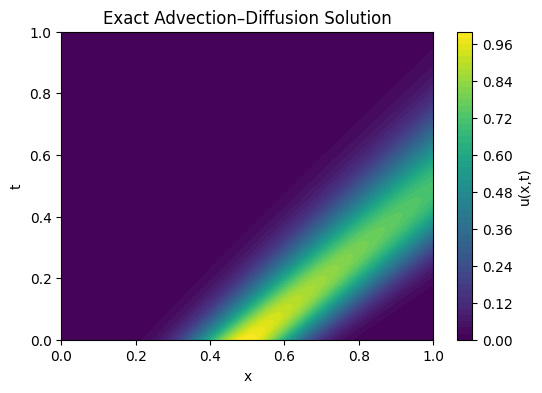

In [44]:
torch.manual_seed(123)

# physical parameters
c = 1.0
D = 0.01

print(f"Advection velocity c: {c}")
print(f"Diffusion coefficient D: {D}")


# --------------------------------------
# test grid (ground truth)
# --------------------------------------

x_test = torch.linspace(0,1,100)
t_test = torch.linspace(0,1,100)

X_test, T_test = torch.meshgrid(x_test, t_test, indexing="ij")

u_exact = exact_solution(c, D, X_test, T_test)

plt.figure(figsize=(6,4))
plt.contourf(X_test, T_test, u_exact, levels=50)
plt.xlabel("x")
plt.ylabel("t")
plt.title("Exact Advection–Diffusion Solution")
plt.colorbar(label="u(x,t)")
plt.show()


# Track Error
X_eval = torch.cat([X_test.reshape(-1,1), T_test.reshape(-1,1)], dim=1)
u_true = exact_solution(c, D, X_eval[:,0:1], X_eval[:,1:2])
u_true = u_true.reshape(100,100)


In [45]:
@dataclass
class NNData:

    # evaluation grid
    X_test: torch.Tensor
    T_test: torch.Tensor
    u_true: torch.Tensor
    X_test_flat: torch.Tensor

    # supervised observations
    X_obs: torch.Tensor
    u_obs: torch.Tensor
    
    
@dataclass
class PINNData:
    # evaluation grid
    X_test: torch.Tensor
    T_test: torch.Tensor
    u_true: torch.Tensor
    X_test_flat: torch.Tensor

    # supervised observations
    X_obs: torch.Tensor
    u_obs: torch.Tensor

    # collocation points
    X_physics: torch.Tensor

    # initial condition
    X_ic: torch.Tensor
    u_ic: torch.Tensor
    
@dataclass
class PDEConfig:
    c: float
    D: float

In [46]:
# Loss

def data_loss(model, X_obs, u_obs):
    u_pred = model(X_obs)
    return torch.mean((u_pred - u_obs) ** 2)

def physics_loss(model, X_physics, pde):
    u = model(X_physics)

    grads = torch.autograd.grad(
        u,
        X_physics,
        torch.ones_like(u),
        create_graph=True
    )[0]

    dudx = grads[:,0:1]
    dudt = grads[:,1:2]

    d2udx2 = torch.autograd.grad(
        dudx,
        X_physics,
        torch.ones_like(dudx),
        create_graph=True
    )[0][:,0:1]

    f = dudt + pde.c * dudx - pde.D * d2udx2

    return torch.mean(f**2)

def ic_loss(model, X_ic, u_ic):
    u_pred = model(X_ic)
    return torch.mean((u_pred - u_ic) ** 2)

In [47]:
def pinn_loss(data, model, pde, lambdas):
    lambda_phys, lambda_ic = lambdas

    L_data = data_loss(model, data.X_obs, data.u_obs)

    L_phys = physics_loss(
        model,
        data.X_physics,
        pde
    )

    L_ic = ic_loss(
        model,
        data.X_ic,
        data.u_ic
    )

    return L_data + lambda_phys * L_phys + lambda_ic * L_ic


def nn_loss(data, model, *_):
    u_pred = model(data.X_obs)

    return torch.mean((u_pred - data.u_obs) ** 2)

In [48]:
def evaluate(step, data, model):
    u_pred = model(data.X_test_flat).detach().reshape(100,100)
    error = relative_l2_error(u_pred, data.u_true)

    print(f"Step {step} | Relative L2 Error: {error.item():.4e}")

    plt.figure(figsize=(6,4))

    plt.contourf(
        data.X_test,
        data.T_test,
        u_pred,
        levels=50,
        cmap="viridis"
    )

    plt.xlabel("x")
    plt.ylabel("t")

    plt.title(
        f"NN solution at step {step}\n"
        f"Rel L2 error = {error.item():.2e}"
    )

    plt.colorbar(label="u(x,t)")
    plt.show()

In [49]:
def train(
    model,
    data,
    optimiser,
    loss_fn,
    num_epochs,
    pde=None,
    lambdas=None
):

    for step in range(num_epochs):

        optimiser.zero_grad()

        loss = loss_fn(data, model, pde, lambdas)

        loss.backward()

        optimiser.step()

        if step % 5000 == 0:
            evaluate(step, data, model)

## Standard Neural Network

In [50]:
nn_model = FCN(2,1,32,3)

#### Obersvation Data

In [51]:
N_obs = 200 # 200 - 500

x_obs = torch.rand(N_obs,1)
t_obs = torch.rand(N_obs,1)
u_obs = exact_solution(c, D, x_obs, t_obs) + 0.02*torch.randn_like(x_obs)

X_obs = torch.cat([x_obs, t_obs], dim=1).requires_grad_(True)

#### Evaluation Grid

In [52]:
X_eval = torch.cat(
    [X_test.reshape(-1,1), T_test.reshape(-1,1)],
    dim=1
)

u_true = exact_solution(
    c, 
    D, 
    X_eval[:,0:1], 
    X_eval[:,1:2]
).reshape(100,100)

#### Create Dataset

In [53]:
nn_data = NNData(
    X_test=X_test,
    T_test=T_test,
    u_true=u_true,
    X_test_flat=X_eval,

    X_obs=X_obs,
    u_obs=u_obs
)

#### Optimiser 

In [54]:
optimiser = torch.optim.Adam(
    nn_model.parameters(),
    lr=1e-3
)

#### PDE Configuration

In [55]:
pde = PDEConfig(
    c=1.0,
    D=0.01
)

#### Train

Step 0 | Relative L2 Error: 1.0601e+00


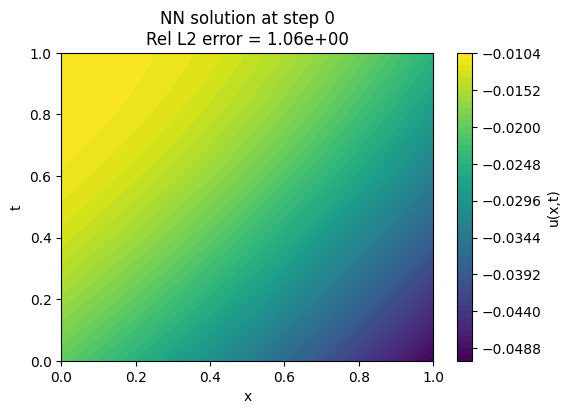

Step 5000 | Relative L2 Error: 2.4249e-02


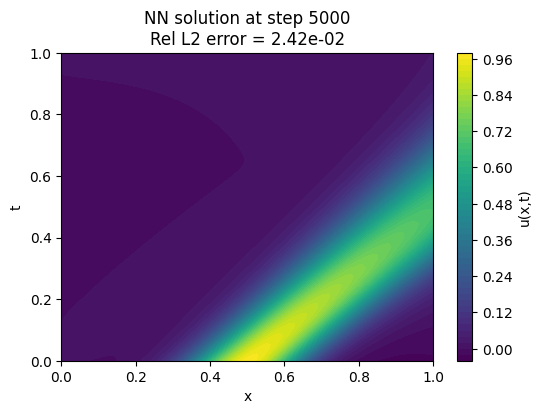

Step 10000 | Relative L2 Error: 2.8473e-02


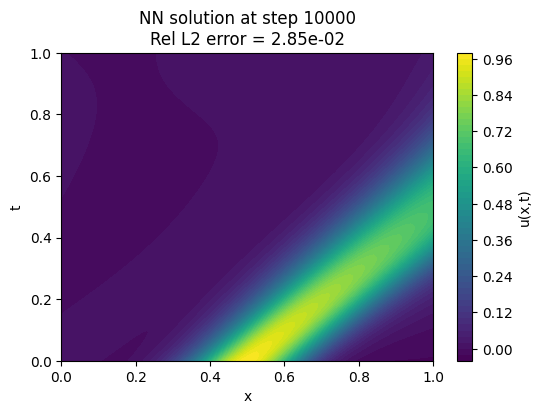

Step 15000 | Relative L2 Error: 4.1040e-02


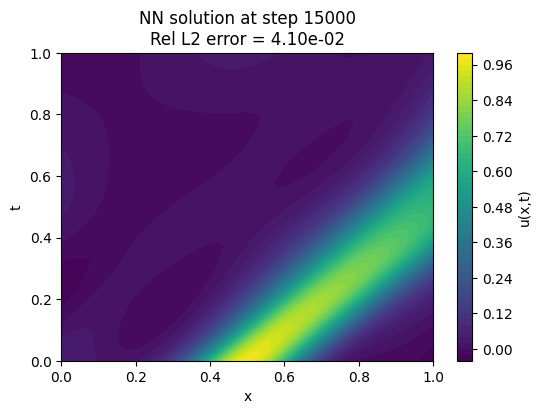

In [56]:
num_epochs = 15001

train(
    model=nn_model,
    data=nn_data,
    optimiser=optimiser,
    loss_fn=nn_loss,
    num_epochs=num_epochs,
)

## Physics Informed Neural Network

In [57]:
# define a neural network to train
pinn_model = FCN(2,1,32,3)

#### Observation Data

In [58]:
N_obs = 20 # 20 - 50

x_obs = torch.rand(N_obs,1)
t_obs = torch.rand(N_obs,1)
u_obs = exact_solution(c, D, x_obs, t_obs) + 0.02*torch.randn_like(x_obs)

X_obs = torch.cat([x_obs, t_obs], dim=1).requires_grad_(True)

#### Physics Points

In [59]:
N_physics =  1000 # 1000 - 10,000

x_physics = torch.rand(N_physics,1, requires_grad=True)
t_physics = torch.rand(N_physics,1, requires_grad=True)
X_physics = torch.cat([x_physics, t_physics], dim=1)

#### Inital Condition Points

In [60]:
N_ic = 100 # 100 - 200

x_ic = torch.rand(N_ic, 1)
X_ic = torch.cat([x_ic, torch.zeros_like(x_ic)], dim=1)  # t=0
u_ic_target = initial_condition(x_ic, c, D)  # target values at t=0

#### Evaluation Grid

In [61]:
X_eval = torch.cat(
    [X_test.reshape(-1,1), T_test.reshape(-1,1)],
    dim=1
)

u_true = exact_solution(
    c, 
    D, 
    X_eval[:,0:1], 
    X_eval[:,1:2]
).reshape(100,100)


#### Create Dataset

In [62]:
pinn_data = PINNData(
    X_test=X_test,
    T_test=T_test,
    u_true=u_true,

    X_test_flat=X_eval,

    X_obs=X_obs,
    u_obs=u_obs,

    X_physics=X_physics,

    X_ic=X_ic,
    u_ic=u_ic_target
)

#### Optimiser 

In [ ]:
optimiser = torch.optim.Adam(
    pinn_model.parameters(),
    lr=1e-3
)

#### PDE Configuration

In [64]:
pde = PDEConfig(
    c=1.0,
    D=0.01
)

### Train

Step 0 | Relative L2 Error: 8.9619e-01


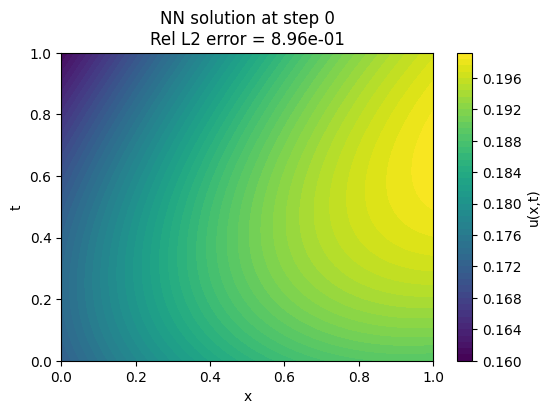

Step 5000 | Relative L2 Error: 9.0828e-02


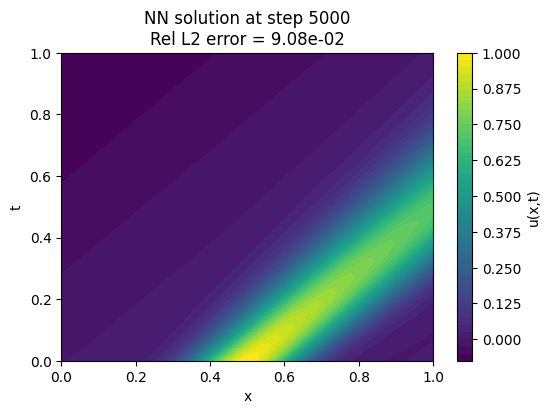

Step 10000 | Relative L2 Error: 5.1145e-02


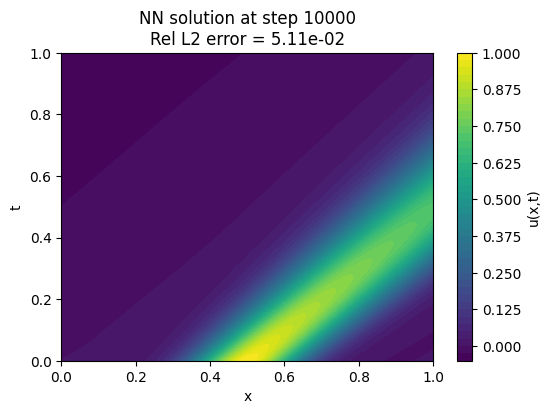

Step 15000 | Relative L2 Error: 3.8772e-02


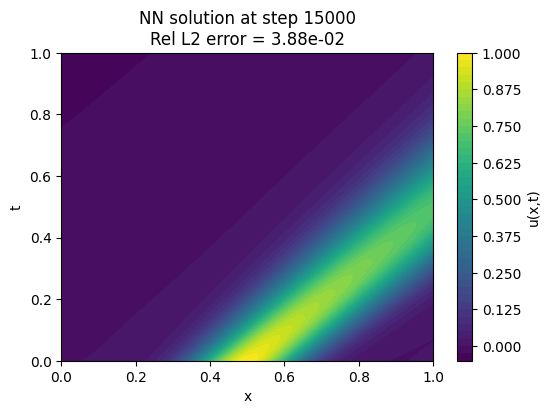

Step 20000 | Relative L2 Error: 2.7990e-02


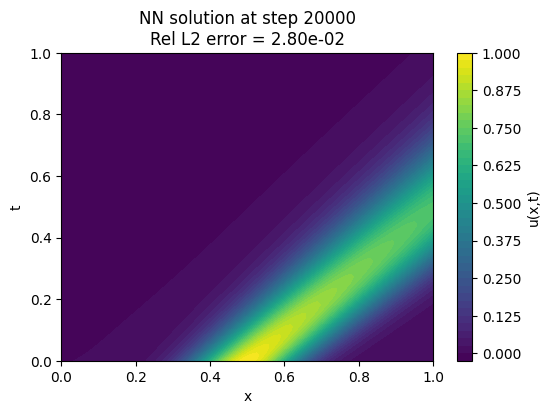

Step 25000 | Relative L2 Error: 2.6980e-02


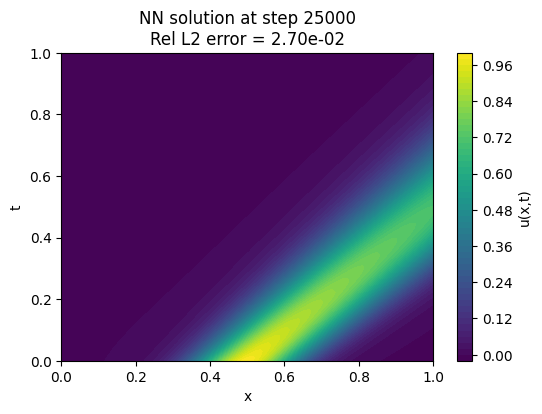

Step 30000 | Relative L2 Error: 2.2709e-02


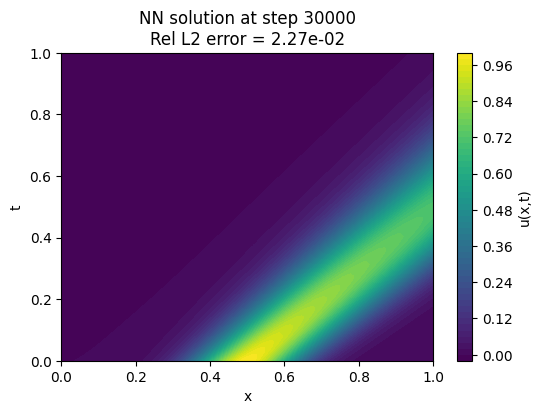

Step 35000 | Relative L2 Error: 3.8539e-02


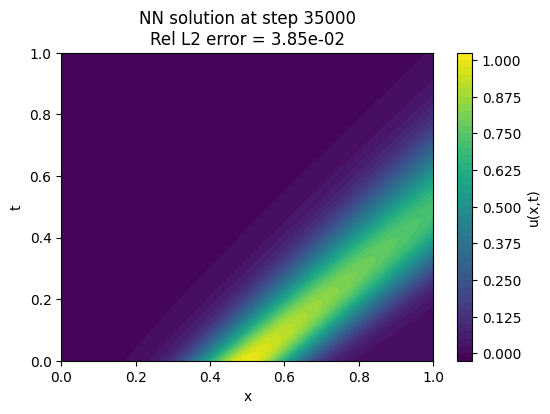

Step 40000 | Relative L2 Error: 3.3730e-02


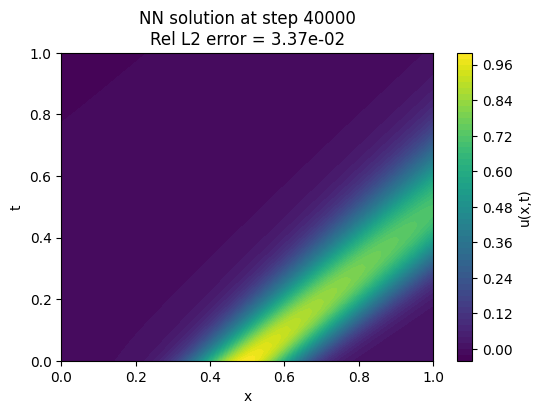

Step 45000 | Relative L2 Error: 3.1609e-02


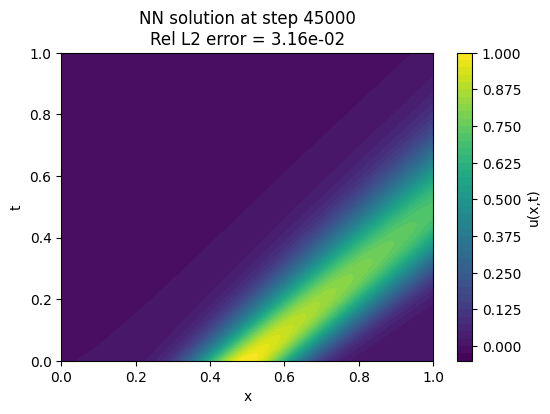

In [ ]:
num_epochs = 15001

train(
    model=pinn_model,
    data=pinn_data,
    optimiser=optimiser,
    loss_fn=pinn_loss,
    num_epochs=num_epochs,
    pde=pde,
    lambdas=[1e2, 1e3]
)